# Amortized neural OT rearrangement on the bimodal Gaussian target

This notebook trains a neural OT map and a coverage-conditioned, measure-preserving rearrangement of that map. During rearrangement training, one coverage mass is sampled uniformly from $(0, 1)$ for every minibatch. The final figure compares the neural OT contour, the amortized rearranged contour at a selected coverage mass, and the two equal-radius, mode-centered target HDR contours.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import chi2

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent.parent

src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from configs.datasets.synthetic import BimodalGaussianDatasetConfig
from configs.predictors.rearranged_transport import (
    AmortizedRearrangedTransportPredictorConfig,
)
from configs.predictors.transport import (
    NormalizingFlowPredictorConfig,
    NeuralOptimalTransportPredictorConfig
)
from configs.trainers.rearranged_transport import (
    AmortizedRearrangedTransportTrainerConfig
)
from configs.trainers.transport import (
    NormalizingFlowTrainerConfig,
    NeuralOptimalTransportTrainerConfig
)
from data.datasets.synthetic import BimodalGaussianDataset
from data.loaders import make_xy_dataloader
from predictors.rearranged_transport import AmortizedRearrangedTransport
from predictors.transport import NormalizingFlowPredictor, NeuralOptimalTransportPredictor
from trainers.rearranged_transport import AmortizedRearrangedTransportTrainer
from trainers.transport import NormalizingFlowTrainer, NeuralOptimalTransportTrainer

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [12]:
seed = 7
torch.manual_seed(seed)
np.random.seed(seed)

device = "cpu"
dtype = "float32"

n_train = 50_000
n_calibration = 1_024
n_test = 1_024
batch_size = 1_024

plotting_coverage_mass = 0.90
x_plot_value = 0.

ot_epochs = 100
ot_warmup_iterations = 10
c_transform_max_iter = 1000

rearrangement_epochs = 100

n_boundary_points = 720
n_hdr_radius_samples = 1_000_000
plot_batch_size = 256

In [13]:
dataset_config = BimodalGaussianDatasetConfig(
    n_train=n_train,
    n_calibration=n_calibration,
    n_test=n_test,
    x_dim=1,
    y_dim=2,
    seed=seed,
    device=device,
    dtype=dtype,
)

dataset = BimodalGaussianDataset(dataset_config)
splits = dataset.get_splits()

train_dataloader = make_xy_dataloader(
    data=splits.train,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

print("train x/y:", splits.train.x.shape, splits.train.y.shape)
print("calibration x/y:", splits.calibration.x.shape, splits.calibration.y.shape)
print("test x/y:", splits.test.x.shape, splits.test.y.shape)

train x/y: torch.Size([50000, 1]) torch.Size([50000, 2])
calibration x/y: torch.Size([1024, 1]) torch.Size([1024, 2])
test x/y: torch.Size([1024, 1]) torch.Size([1024, 2])


In [14]:
predictor_config = NeuralOptimalTransportPredictorConfig(
    x_dim=dataset.x_dim,
    y_dim=dataset.y_dim,
    hidden_dim=128,
    num_hidden_layers=8,
    c_transform_lr=1.,
    c_transform_max_iter=1000,
    seed=seed,
    device=device,
    dtype=dtype,
)

trainer_config = NeuralOptimalTransportTrainerConfig(
    epochs=100,
    learning_rate=1e-3,
    weight_decay=1e-4,
    warmup_iterations=ot_warmup_iterations,
    grad_clip_norm=1.0,
    use_cosine_scheduler=True,
    verbose=True,
)

predictor = NeuralOptimalTransportPredictor(predictor_config)
trainer = NeuralOptimalTransportTrainer(trainer_config)

# predictor = predictor.load("../../weights/neural_ot_predictor.pt")

predictor = trainer.fit(
    predictor=predictor,
    dataloader=train_dataloader,
)
predictor.eval()

trainer.training_history[-5:]

Warmup 10 | Loss 0.0337: 100%|██████████| 10/10 [00:15<00:00,  1.60s/it]
Epoch 100 | Potential loss 1.9985: 100%|██████████| 100/100 [16:14<00:00,  9.75s/it]


[{'epoch': 96,
  'potential_loss': 1.9941993951797485,
  'epoch_time': 9.808036333997734,
  'learning_rate': 3.942649342761125e-06},
 {'epoch': 97,
  'potential_loss': 1.9998489618301392,
  'epoch_time': 10.007819665996067,
  'learning_rate': 2.219017698460006e-06},
 {'epoch': 98,
  'potential_loss': 1.9946321249008179,
  'epoch_time': 9.536406582999916,
  'learning_rate': 9.866357858642221e-07},
 {'epoch': 99,
  'potential_loss': 1.9970661401748657,
  'epoch_time': 9.938226332997147,
  'learning_rate': 2.467198171342003e-07},
 {'epoch': 100,
  'potential_loss': 1.998517394065857,
  'epoch_time': 9.83931208300055,
  'learning_rate': 0.0}]

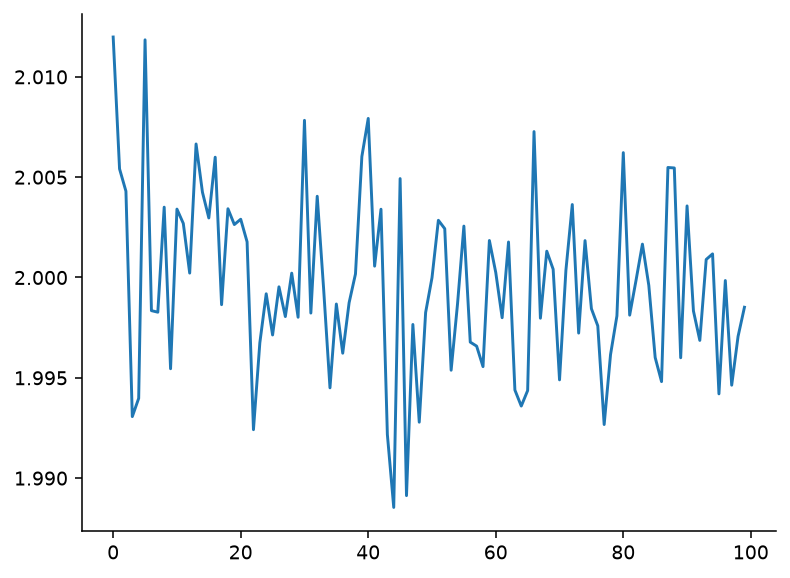

In [15]:
plt.plot([epoch['potential_loss'] for epoch in trainer.training_history])
plt.show()

## Base neural-OT HDR diagnostic

Before training the rearrangement, compare (i) the base model's pushforward of the Gaussian probability ball, (ii) the target bimodal HDR represented by equal-radius circles centered at the two modes, and (iii) the base model's HDR obtained from its learned change-of-variables density. The common target HDR radius is calibrated by Monte Carlo so that the union of the two circles has the requested probability mass.

$$\log p_\theta(T_\theta(u)\mid x)=\log\phi(u)-\log\left|\det D_uT_\theta(u;x)\right|.$$

The learned density threshold is estimated by Monte Carlo under the base neural-OT model, then its level set is extracted in latent space and pushed forward for display in target space.

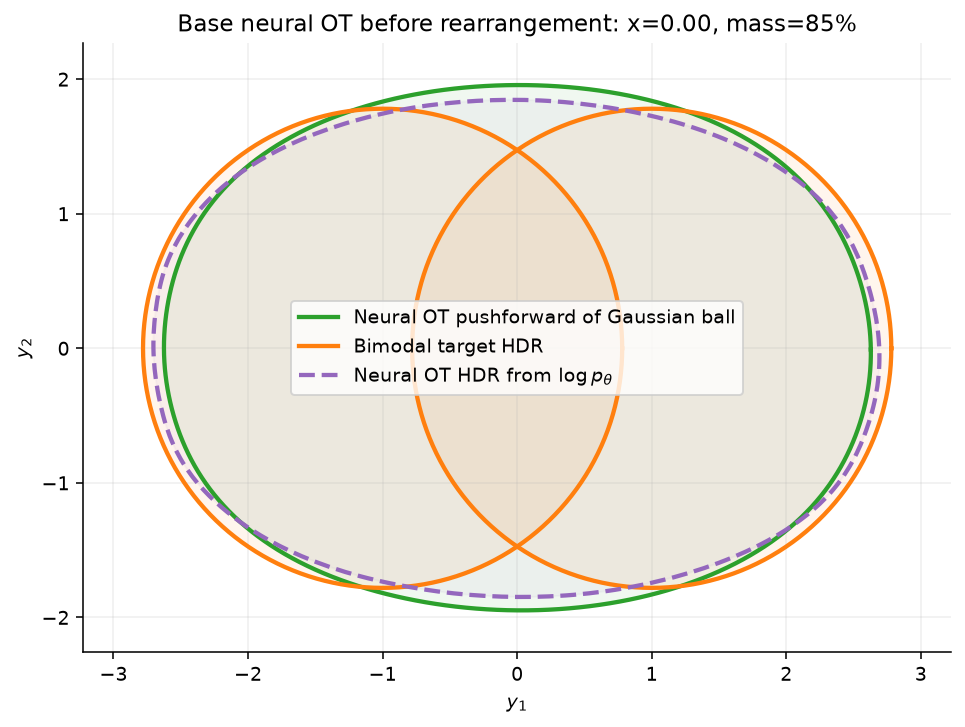

Learned log-p threshold: -3.9359
Monte Carlo mass above threshold: 0.850
Learned HDR contour components: 1
Bimodal HDR radius: 1.7805
Bimodal HDR Monte Carlo mass: 0.8500
Bimodal HDR circles are disjoint: False


In [16]:
plotting_coverage_mass = 0.85

n_log_prob_calibration_samples = 1_000
log_prob_grid_resolution = 181


def _hdr_repeated_x(n_points):
    return torch.full(
        (n_points, dataset.x_dim),
        x_plot_value,
        device=dataset.device,
        dtype=dataset.dtype,
    )


def _hdr_circle(radius, n_points=n_boundary_points):
    angles = np.linspace(0.0, 2.0 * np.pi, n_points, endpoint=False)
    return torch.as_tensor(
        radius * np.column_stack((np.cos(angles), np.sin(angles))),
        device=dataset.device,
        dtype=dataset.dtype,
    )


def _hdr_close_contour(points):
    return np.vstack((points, points[:1]))


def _estimate_bimodal_hdr_radius(coverage_mass, n_samples):
    target_samples = dataset.sample_target(n_samples)
    nearest_mode_distance = torch.linalg.vector_norm(
        target_samples[:, None, :] - dataset.modes[None, :, :],
        dim=-1,
    ).amin(dim=1)
    rank = int(np.ceil(coverage_mass * nearest_mode_distance.numel()))
    rank = max(1, min(rank, nearest_mode_distance.numel()))
    radius = torch.kthvalue(nearest_mode_distance, rank).values
    empirical_mass = (nearest_mode_distance <= radius).float().mean()
    return float(radius.cpu()), float(empirical_mass.cpu())


def _hdr_bimodal_contours(radius):
    centered_circle = _hdr_circle(radius)
    return [
        _hdr_close_contour((centered_circle + mode).cpu().numpy())
        for mode in dataset.modes
    ]


def _hdr_neural_pushforward(u):
    mapped_batches = []
    for start in range(0, len(u), plot_batch_size):
        u_batch = u[start:start + plot_batch_size]
        mapped_batches.append(
            predictor.pushforward(x=_hdr_repeated_x(len(u_batch)), u=u_batch).cpu()
        )
    return torch.cat(mapped_batches, dim=0)


def _hdr_neural_log_prob_from_u(u):
    log_prob_batches = []
    gaussian_constant = dataset.y_dim * np.log(2.0 * np.pi)
    for start in range(0, len(u), plot_batch_size):
        u_batch = u[start:start + plot_batch_size]
        base_log_prob = -0.5 * (u_batch.square().sum(dim=-1) + gaussian_constant)
        transport_log_det = predictor.log_det(
            x=_hdr_repeated_x(len(u_batch)),
            u=u_batch,
            create_graph=False,
            jitter=0.,
        )
        log_prob_batches.append((base_log_prob - transport_log_det).detach().cpu())
    return torch.cat(log_prob_batches, dim=0)


source_radius = float(np.sqrt(chi2.ppf(plotting_coverage_mass, df=dataset.y_dim)))
source_boundary = _hdr_circle(source_radius)
neural_ball_contour = _hdr_close_contour(
    _hdr_neural_pushforward(source_boundary).numpy()
)
oracle_hdr_radius, oracle_hdr_mc_mass = _estimate_bimodal_hdr_radius(
    plotting_coverage_mass,
    n_hdr_radius_samples,
)
oracle_hdr_contours = _hdr_bimodal_contours(oracle_hdr_radius)
mode_separation = float(
    torch.linalg.vector_norm(dataset.modes[0] - dataset.modes[1]).cpu()
)
oracle_hdr_components_disjoint = 2.0 * oracle_hdr_radius < mode_separation

# Calibrate the learned-density level using samples from the base neural-OT model.
hdr_generator = torch.Generator(device='cpu').manual_seed(seed + 10_000)
calibration_u = torch.randn(
    n_log_prob_calibration_samples,
    dataset.y_dim,
    generator=hdr_generator,
    dtype=dataset.dtype,
).to(dataset.device)
calibration_log_prob = _hdr_neural_log_prob_from_u(calibration_u)
learned_log_prob_threshold = float(
    torch.quantile(calibration_log_prob, 1.0 - plotting_coverage_mass)
)
mc_mass = float((calibration_log_prob >= learned_log_prob_threshold).float().mean())

# Extract the learned log-density level set in latent space.
log_prob_grid_limit = max(0.1, 1.8 * source_radius)
grid_axis = np.linspace(-log_prob_grid_limit, log_prob_grid_limit, log_prob_grid_resolution)
grid_u1, grid_u2 = np.meshgrid(grid_axis, grid_axis)
grid_u = torch.as_tensor(
    np.column_stack((grid_u1.ravel(), grid_u2.ravel())),
    device=dataset.device,
    dtype=dataset.dtype,
)
grid_log_prob = _hdr_neural_log_prob_from_u(grid_u).numpy().reshape(grid_u1.shape)
if not grid_log_prob.min() <= learned_log_prob_threshold <= grid_log_prob.max():
    raise RuntimeError('The learned HDR level is outside the latent plotting grid.')

temporary_figure, temporary_axis = plt.subplots()
latent_contour_set = temporary_axis.contour(
    grid_u1,
    grid_u2,
    grid_log_prob,
    levels=[learned_log_prob_threshold],
)
latent_hdr_segments = [
    segment for segment in latent_contour_set.allsegs[0] if len(segment) >= 3
]
plt.close(temporary_figure)
if not latent_hdr_segments:
    raise RuntimeError('No learned HDR contour was found on the latent plotting grid.')

learned_hdr_contours = []
for segment in latent_hdr_segments:
    segment_u = torch.as_tensor(segment, device=dataset.device, dtype=dataset.dtype)
    learned_hdr_contours.append(
        _hdr_close_contour(_hdr_neural_pushforward(segment_u).numpy())
    )

figure, axis = plt.subplots(figsize=(8, 7))
axis.fill(*neural_ball_contour.T, color='tab:green', alpha=0.07)
axis.plot(
    *neural_ball_contour.T,
    color='tab:green',
    linewidth=2.2,
    label='Neural OT pushforward of Gaussian ball',
)
for component_index, contour in enumerate(oracle_hdr_contours):
    axis.fill(*contour.T, color='tab:orange', alpha=0.07)
    axis.plot(
        *contour.T,
        color='tab:orange',
        linewidth=2.2,
        label='Bimodal target HDR' if component_index == 0 else None,
    )
for segment_index, contour in enumerate(learned_hdr_contours):
    axis.fill(*contour.T, color='tab:purple', alpha=0.05)
    axis.plot(
        *contour.T,
        color='tab:purple',
        linestyle='--',
        linewidth=2.2,
        label=r'Neural OT HDR from $\log p_\theta$' if segment_index == 0 else None,
    )

all_contour_points = np.vstack(
    [neural_ball_contour, *oracle_hdr_contours, *learned_hdr_contours]
)
lower = all_contour_points.min(axis=0)
upper = all_contour_points.max(axis=0)
margin = 0.08 * np.maximum(upper - lower, 1e-6)
axis.set_xlim(lower[0] - margin[0], upper[0] + margin[0])
axis.set_ylim(lower[1] - margin[1], upper[1] + margin[1])
axis.set_aspect('equal', adjustable='box')
axis.set_xlabel(r'$y_1$')
axis.set_ylabel(r'$y_2$')
axis.set_title(
    f'Base neural OT before rearrangement: x={x_plot_value:.2f}, '
    f'mass={plotting_coverage_mass:.0%}'
)
axis.grid(alpha=0.2)
axis.legend()
plt.show()

print(f'Learned log-p threshold: {learned_log_prob_threshold:.4f}')
print(f'Monte Carlo mass above threshold: {mc_mass:.3f}')
print(f'Learned HDR contour components: {len(learned_hdr_contours)}')
print(f'Bimodal HDR radius: {oracle_hdr_radius:.4f}')
print(f'Bimodal HDR Monte Carlo mass: {oracle_hdr_mc_mass:.4f}')
print(f'Bimodal HDR circles are disjoint: {oracle_hdr_components_disjoint}')

In [7]:
amortized_predictor_config = AmortizedRearrangedTransportPredictorConfig(
    x_dim=dataset.x_dim,
    y_dim=dataset.y_dim,
    hidden_dimension=32,
    number_of_hidden_layers=9,
    use_adjoint=False,
    method="dopri5",
    rtol=0.0001,
    atol=0.00001,
    vector_field_implementation="sparse",
    activation="silu",
    seed=seed,
    device=device,
    dtype=dtype,
)

amortized_predictor = AmortizedRearrangedTransport(
    config=amortized_predictor_config,
    transport_predictor=predictor,
)

amortized_trainer_config = AmortizedRearrangedTransportTrainerConfig(
    epochs=rearrangement_epochs,
    train_transport_map=False,
    learning_rate=1e-3,
    weight_decay=1e-4,
    mc_samples_per_x=16,
    grad_clip_norm=1.0,
    use_cosine_scheduler=True,
    verbose=True,
)

amortized_trainer = AmortizedRearrangedTransportTrainer(
    amortized_trainer_config
)
amortized_predictor = amortized_trainer.fit(
    predictor=amortized_predictor,
    dataloader=train_dataloader,
)
amortized_predictor.eval()

amortized_trainer.training_history[-5:]

Amortized Rearranged Transport:   0%|          | 0/100 [00:06<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
plt.plot([epoch['log_volume_loss'] for epoch in amortized_trainer.training_history])
plt.show()

In [ ]:
def circle_boundary(radius, n_points, center=(0.0, 0.0)):
    theta = np.linspace(0.0, 2.0 * np.pi, n_points, endpoint=False)
    boundary = (
        np.asarray(center, dtype=float)
        + np.column_stack([np.cos(theta), np.sin(theta)]) * radius
    )
    return torch.as_tensor(boundary, device=dataset.device, dtype=dataset.dtype)


def close_contour(contour):
    contour = np.asarray(contour)
    if np.allclose(contour[0], contour[-1]):
        return contour
    return np.vstack([contour, contour[0]])


def repeated_x(batch_size, x_value=x_plot_value):
    return torch.full(
        (batch_size, dataset.x_dim),
        fill_value=x_value,
        device=dataset.device,
        dtype=dataset.dtype,
    )


def model_pushforward_contour(
    model,
    u,
    coverage_mass=None,
    batch_size=plot_batch_size,
):
    mapped = []
    for start in range(0, u.shape[0], batch_size):
        u_batch = u[start:start + batch_size]
        x_batch = repeated_x(u_batch.shape[0]).to(u_batch)

        if coverage_mass is None:
            y_batch = model.pushforward(x=x_batch, u=u_batch)
        else:
            y_batch = model.pushforward(
                x=x_batch,
                u=u_batch,
                coverage_mass=coverage_mass,
            )

        mapped.append(y_batch.detach().cpu())

    return close_contour(torch.cat(mapped, dim=0).numpy())


def bimodal_hdr_contours(radius):
    return [
        close_contour(
            circle_boundary(
                radius=radius,
                n_points=n_boundary_points,
                center=mode.detach().cpu().numpy(),
            ).cpu().numpy()
        )
        for mode in dataset.modes
    ]


def contour_bounds(contours, side_margin=0.05, bottom_margin=0.10, top_margin=0.20):
    points = np.vstack([np.asarray(contour) for contour in contours])
    xmin, ymin = points.min(axis=0)
    xmax, ymax = points.max(axis=0)
    width = max(xmax - xmin, 1e-12)
    height = max(ymax - ymin, 1e-12)
    return (
        xmin - side_margin * width,
        xmax + side_margin * width,
        ymin - bottom_margin * height,
        ymax + top_margin * height,
    )


In [ ]:
plotting_coverage_mass = 0.75

r_source = float(
    np.sqrt(chi2.ppf(plotting_coverage_mass, df=dataset.y_dim))
)
source_ball_boundary = circle_boundary(
    radius=r_source,
    n_points=n_boundary_points,
)

neural_ot_contour = model_pushforward_contour(
    predictor,
    source_ball_boundary,
)
amortized_contour = model_pushforward_contour(
    amortized_predictor,
    source_ball_boundary,
    coverage_mass=plotting_coverage_mass,
)
oracle_hdr_radius, oracle_hdr_mc_mass = _estimate_bimodal_hdr_radius(
    plotting_coverage_mass,
    n_hdr_radius_samples,
)
oracle_hdr_contours = bimodal_hdr_contours(oracle_hdr_radius)
mode_separation = float(
    torch.linalg.vector_norm(dataset.modes[0] - dataset.modes[1]).cpu()
)
oracle_hdr_components_disjoint = 2.0 * oracle_hdr_radius < mode_separation

xmin, xmax, ymin, ymax = contour_bounds([
    neural_ot_contour,
    amortized_contour,
    *oracle_hdr_contours,
])

print(f"coverage_mass = {plotting_coverage_mass:.3f}")
print(f"x = {x_plot_value:.3f}")
print(f"source radius = {r_source:.4f}")
print(f"bimodal HDR radius = {oracle_hdr_radius:.4f}")
print(f"bimodal HDR Monte Carlo mass = {oracle_hdr_mc_mass:.4f}")
print(f"bimodal HDR circles are disjoint = {oracle_hdr_components_disjoint}")

fig, ax = plt.subplots(figsize=(5.8, 4.8), constrained_layout=True)

ax.plot(
    neural_ot_contour[:, 0],
    neural_ot_contour[:, 1],
    color="forestgreen",
    linewidth=2.0,
    label="Neural OT",
)
ax.plot(
    amortized_contour[:, 0],
    amortized_contour[:, 1],
    color="royalblue",
    linewidth=2.0,
    label="Amortized rearranged Neural OT",
)
for component_index, contour in enumerate(oracle_hdr_contours):
    ax.fill(
        contour[:, 0],
        contour[:, 1],
        color="darkorange",
        alpha=0.08,
    )
    ax.plot(
        contour[:, 0],
        contour[:, 1],
        color="darkorange",
        linewidth=2.0,
        label="Bimodal target HDR" if component_index == 0 else None,
    )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$y_1$")
ax.set_ylabel(r"$y_2$")
ax.set_title(
    rf"Neural OT regions and bimodal HDR at $x={x_plot_value:.1f}$, "
    rf"mass={plotting_coverage_mass:.2f}"
)
ax.legend(frameon=False, loc="upper right")

# fig.savefig(
#     output_path,
#     format="pdf",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     metadata={"Creator": "Matplotlib"},
# )

plt.show()


In [ ]:
u = torch.randn(
    1024,
    dataset.y_dim,
    device=dataset.device,
    dtype=dataset.dtype,
)
x = repeated_x(u.shape[0]).to(u)
u_np = u.detach().cpu().numpy()
u_pf_np = amortized_predictor.rearrangement_pushforward(
    x=x,
    u=u,
    coverage_mass=plotting_coverage_mass,
).detach().cpu().numpy()


x_boundary = repeated_x(source_ball_boundary.shape[0]).to(
    source_ball_boundary
)

scale_to_pf_boundary = {}
scale_to_sc_boundary = {}
for scale in [1., 2., 3., 4., 5., 6., 7., 8.]:
    scale /= 8.
    scaled_source_boundary = source_ball_boundary * scale
    scale_to_sc_boundary[scale] = (
        scaled_source_boundary.detach().cpu().numpy()
    )
    scale_to_pf_boundary[scale] = (
        amortized_predictor.rearrangement_pushforward(
            x=x_boundary,
            u=scaled_source_boundary,
            coverage_mass=plotting_coverage_mass,
        ).detach().cpu().numpy()
    )


In [ ]:
plt.scatter(u_np[:, 0], u_np[:, 1])
plt.scatter(u_pf_np[:, 0], u_pf_np[:, 1])
plt.show()

for scale in scale_to_sc_boundary.keys():

    plt.plot(scale_to_sc_boundary[scale][:, 0], scale_to_sc_boundary[scale][:, 1], c="red")
    plt.plot(scale_to_pf_boundary[scale][:, 0], scale_to_pf_boundary[scale][:, 1], c='green')
    
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display
from matplotlib.colors import Normalize

_velocity_grid_resolution = 17
_velocity_plot_limit = 1.3 * r_source
_velocity_plot_axis = np.linspace(
    -_velocity_plot_limit,
    _velocity_plot_limit,
    _velocity_grid_resolution,
)
_velocity_u_1, _velocity_u_2 = np.meshgrid(
    _velocity_plot_axis,
    _velocity_plot_axis,
    indexing="xy",
)
_velocity_plot_points = np.column_stack([
    _velocity_u_1.ravel(),
    _velocity_u_2.ravel(),
])
_velocity_plot_points_tensor = torch.as_tensor(
    _velocity_plot_points,
    device=amortized_predictor.device,
    dtype=amortized_predictor.dtype,
)
_velocity_source_boundary = close_contour(
    source_ball_boundary.detach().cpu().numpy()
)


def _evaluate_velocity_field(time, batch_size=256):
    velocity_batches = []
    vector_field = amortized_predictor.rearrangement_flow.vector_field

    for start in range(0, _velocity_plot_points_tensor.shape[0], batch_size):
        states = (
            _velocity_plot_points_tensor[start:start + batch_size]
            .detach()
            .clone()
            .requires_grad_(True)
        )
        covariates = states.new_full(
            (states.shape[0], amortized_predictor.x_dim),
            float(x_plot_value),
        )
        coverage = states.new_full(
            (states.shape[0], 1),
            float(plotting_coverage_mass),
        )
        context = torch.cat([covariates, coverage], dim=-1)

        with torch.enable_grad():
            velocity = vector_field(u=states, x=context, t=float(time))

        velocity_batches.append(velocity.detach().cpu())

    return (
        torch.cat(velocity_batches, dim=0)
        .numpy()
        .reshape(_velocity_grid_resolution, _velocity_grid_resolution, 2)
    )


_velocity_time_selector = widgets.FloatsInput(
    value=[0.0, 0.25, 0.5, 0.75, 1.0],
    min=0.0,
    max=1.0,
    step=0.05,
    format=".2f",
    allow_duplicates=False,
    description="Timesteps:",
    layout=widgets.Layout(width="600px"),
    style={"description_width": "initial"},
)
_velocity_plot_button = widgets.Button(
    description="Plot velocity fields",
    icon="refresh",
)
_velocity_plot_output = widgets.Output()
_velocity_figure = None


def _plot_selected_velocity_fields(_=None):
    global _velocity_figure

    selected_times = tuple(sorted({
        float(time) for time in _velocity_time_selector.value
    }))

    with _velocity_plot_output:
        _velocity_plot_output.clear_output(wait=True)

        if _velocity_figure is not None:
            plt.close(_velocity_figure)
            _velocity_figure = None

        if not selected_times:
            print("Select at least one timestep between 0 and 1.")
            return

        if any(time < 0.0 or time > 1.0 for time in selected_times):
            print("All selected timesteps must be between 0 and 1.")
            return

        amortized_predictor.eval()
        velocity_fields = [
            _evaluate_velocity_field(time) for time in selected_times
        ]
        speeds = [
            np.linalg.norm(velocity, axis=-1)
            for velocity in velocity_fields
        ]
        maximum_speed = max(float(speed.max()) for speed in speeds)
        display_maximum_speed = max(maximum_speed, np.finfo(float).eps)
        color_normalization = Normalize(
            vmin=0.0,
            vmax=display_maximum_speed,
        )
        grid_spacing = _velocity_plot_axis[1] - _velocity_plot_axis[0]
        quiver_scale = display_maximum_speed / (0.75 * grid_spacing)

        number_of_columns = min(3, len(selected_times))
        number_of_rows = int(np.ceil(len(selected_times) / number_of_columns))
        _velocity_figure, axes = plt.subplots(
            number_of_rows,
            number_of_columns,
            figsize=(4.0 * number_of_columns, 3.7 * number_of_rows),
            sharex=True,
            sharey=True,
            squeeze=False,
            constrained_layout=True,
        )
        visible_axes = []
        quiver = None

        for axis, time, velocity, speed in zip(
            axes.flat, selected_times, velocity_fields, speeds
        ):
            quiver = axis.quiver(
                _velocity_u_1,
                _velocity_u_2,
                velocity[..., 0],
                velocity[..., 1],
                speed,
                cmap="viridis",
                norm=color_normalization,
                angles="xy",
                scale_units="xy",
                scale=quiver_scale,
                pivot="mid",
                width=0.004,
            )
            axis.plot(
                _velocity_source_boundary[:, 0],
                _velocity_source_boundary[:, 1],
                color="0.35",
                linestyle="--",
                linewidth=1.0,
                alpha=0.8,
            )
            axis.set(
                xlim=(-_velocity_plot_limit, _velocity_plot_limit),
                ylim=(-_velocity_plot_limit, _velocity_plot_limit),
                aspect="equal",
                xlabel=r"$u_1$",
                ylabel=r"$u_2$",
                title=rf"$t={time:.2f}$",
            )
            axis.grid(alpha=0.15)
            visible_axes.append(axis)

        for axis in axes.flat[len(selected_times):]:
            _velocity_figure.delaxes(axis)

        colorbar = _velocity_figure.colorbar(
            quiver,
            ax=visible_axes,
            shrink=0.82,
            pad=0.02,
        )
        _velocity_figure.suptitle(
            "Learned amortized rearrangement velocity field "
            rf"at $x={x_plot_value:.2f}$, mass={plotting_coverage_mass:.2f}"
        )
        plt.show()


_velocity_plot_button.on_click(_plot_selected_velocity_fields)
display(widgets.VBox([
    widgets.HTML(
        "Select one or more timesteps in [0, 1], then refresh the plot."
    ),
    _velocity_time_selector,
    _velocity_plot_button,
    _velocity_plot_output,
]))
_plot_selected_velocity_fields()
